In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv('heart_disease_uci.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (920, 16)
Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
trestbps,59,6.41
chol,30,3.26
fbs,90,9.78
restecg,2,0.22
thalch,55,5.98
exang,55,5.98
oldpeak,62,6.74
slope,309,33.59
ca,611,66.41
thal,486,52.83


In [5]:
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['id', 'dataset', 'num'])
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
bool_cols = ['fbs', 'exang']
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in bool_cols:
    df[col] = df[col].astype('boolean').fillna(False).astype(int)
print('Missing values after cleaning:', df.isnull().sum().sum())
print('Shape after cleaning:', df.shape)

Missing values after cleaning: 0
Shape after cleaning: (920, 14)


In [6]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,0.782609,131.995652,199.908696,0.150000,0.990217,137.692391,0.366304,0.853261,1.152174,0.227174,1.158696,0.553261
std,9.424685,0.408148,0.956350,18.451300,109.040171,0.357266,0.631863,25.145235,0.482056,1.058049,0.516007,0.628936,0.483493,0.497426
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,177.750000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,140.000000,0.000000,0.500000,1.000000,0.000000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,1.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


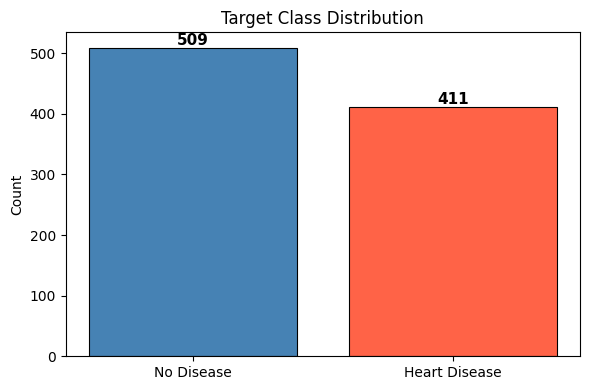

In [7]:
plt.figure(figsize=(6, 4))
counts = df['target'].value_counts()
bars = plt.bar(['No Disease', 'Heart Disease'], counts.values,
               color=['steelblue', 'tomato'], edgecolor='k', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold', fontsize=11)
plt.title('Target Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

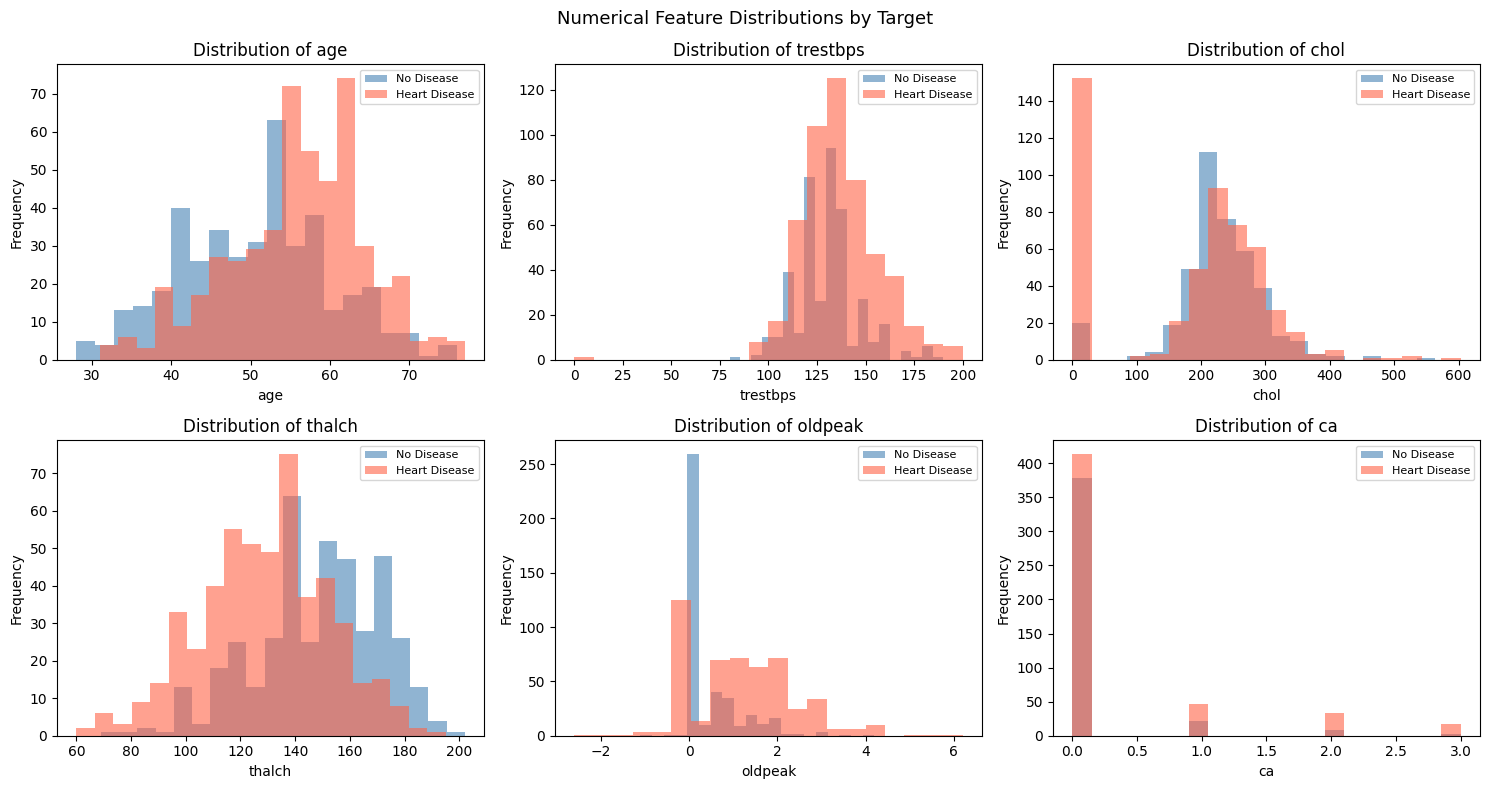

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numerical_cols):
    for val, label, color in [(0, 'No Disease', 'steelblue'), (1, 'Heart Disease', 'tomato')]:
        ax.hist(df[df['target'] == val][col], alpha=0.6, bins=20, label=label, color=color)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
plt.suptitle('Numerical Feature Distributions by Target', fontsize=13)
plt.tight_layout()
plt.show()

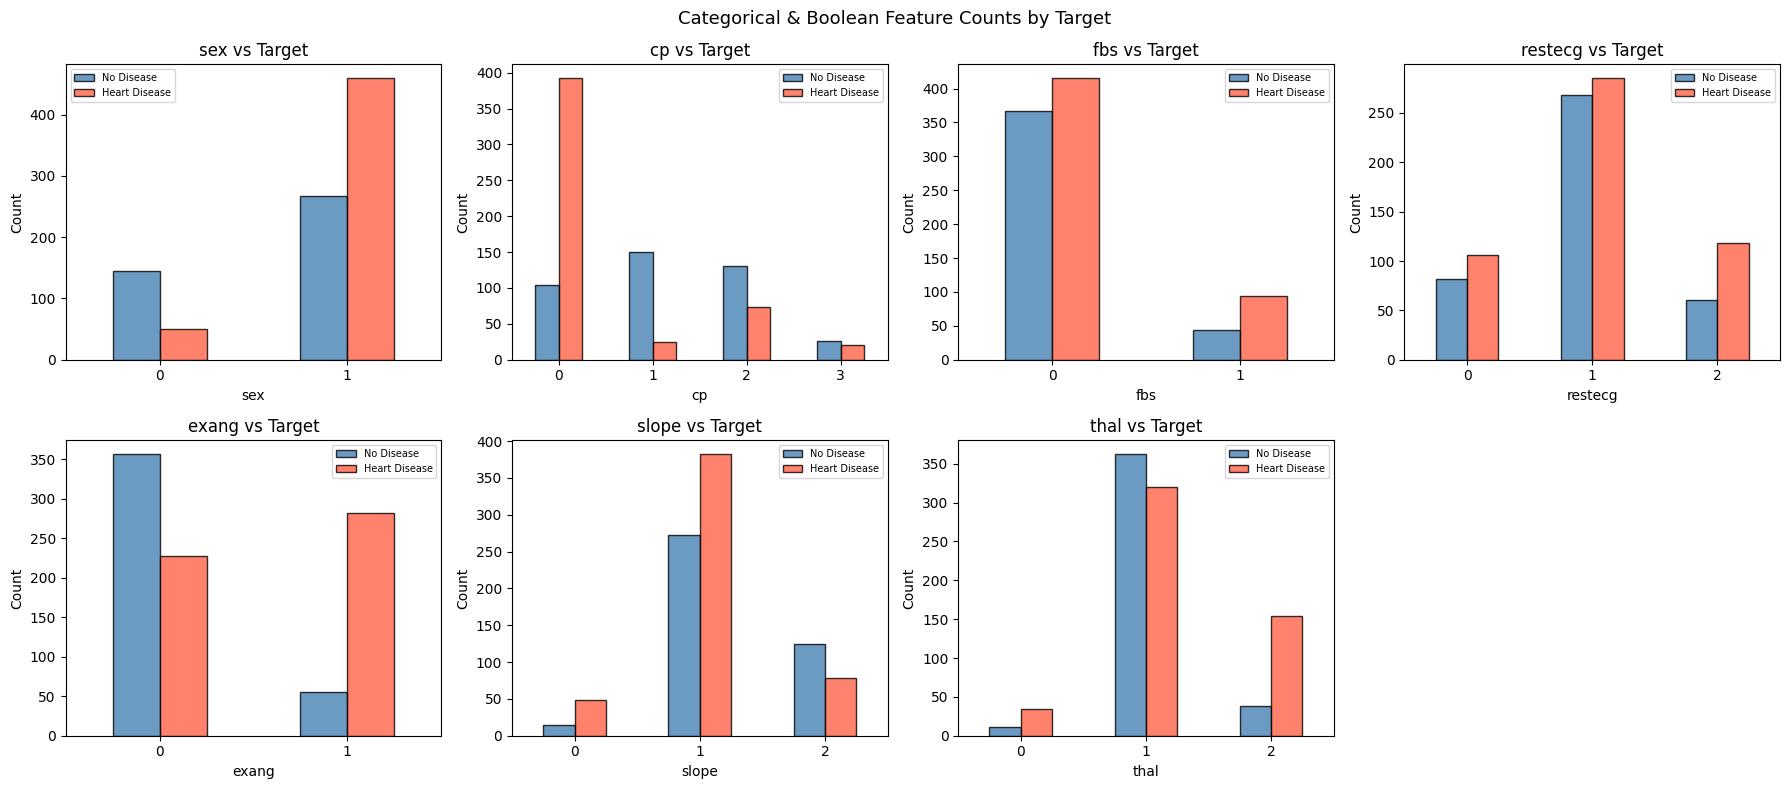

In [9]:
orig_cats = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), orig_cats):
    ct = df.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], alpha=0.8, edgecolor='k')
    ax.set_title(f'{col} vs Target')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(['No Disease', 'Heart Disease'], fontsize=7)
    ax.tick_params(axis='x', rotation=0)
axes.flatten()[-1].set_visible(False)
plt.suptitle('Categorical & Boolean Feature Counts by Target', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\siddi\AppData\Local\Temp\ipykernel_5628\2439941519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, palette=['steelblue', 'tomato'], ax=ax)
C:\Users\siddi\AppData\Local\Temp\ipykernel_5628\2439941519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, palette=['steelblue', 'tomato'], ax=ax)
C:\Users\siddi\AppData\Local\Temp\ipykernel_5628\2439941519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, palette=['steelblue', 'tomato'], ax=ax)
C:\User

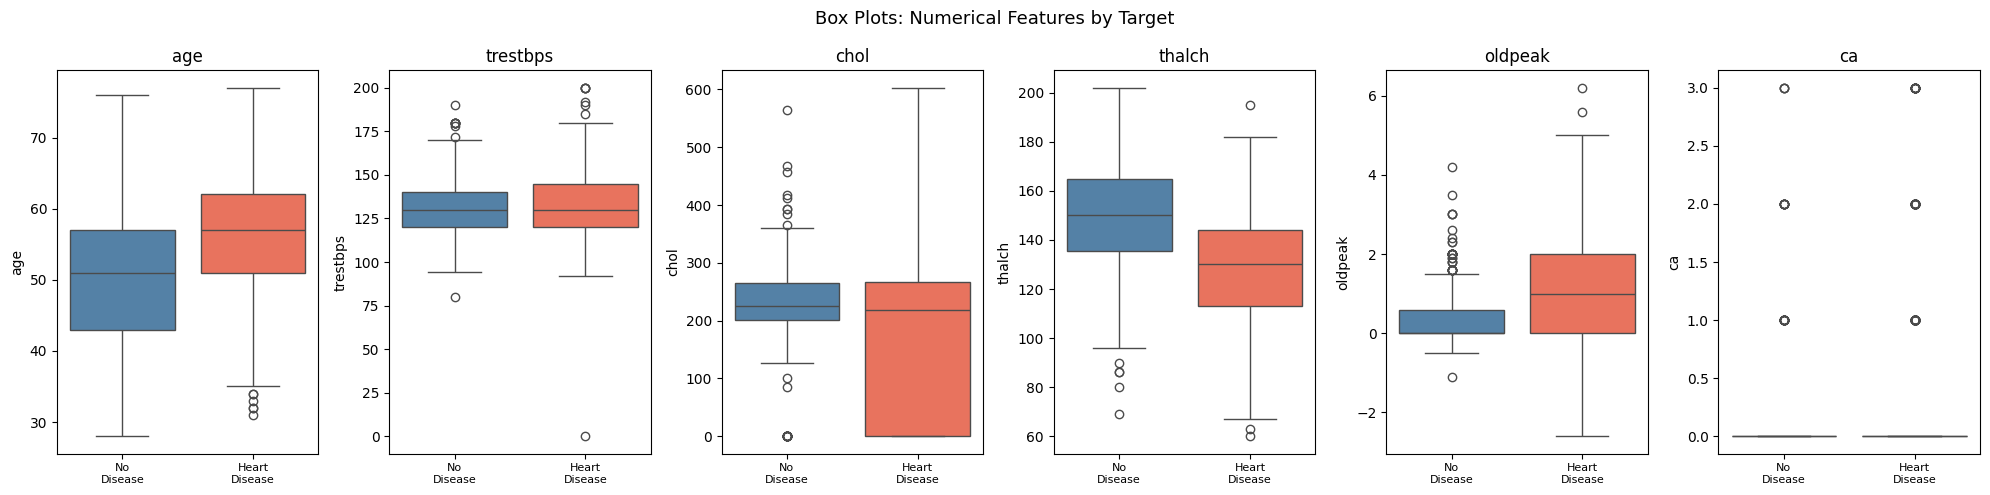

In [10]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 5))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(data=df, x='target', y=col, palette=['steelblue', 'tomato'], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No\nDisease', 'Heart\nDisease'], fontsize=8)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Box Plots: Numerical Features by Target', fontsize=13)
plt.tight_layout()
plt.show()

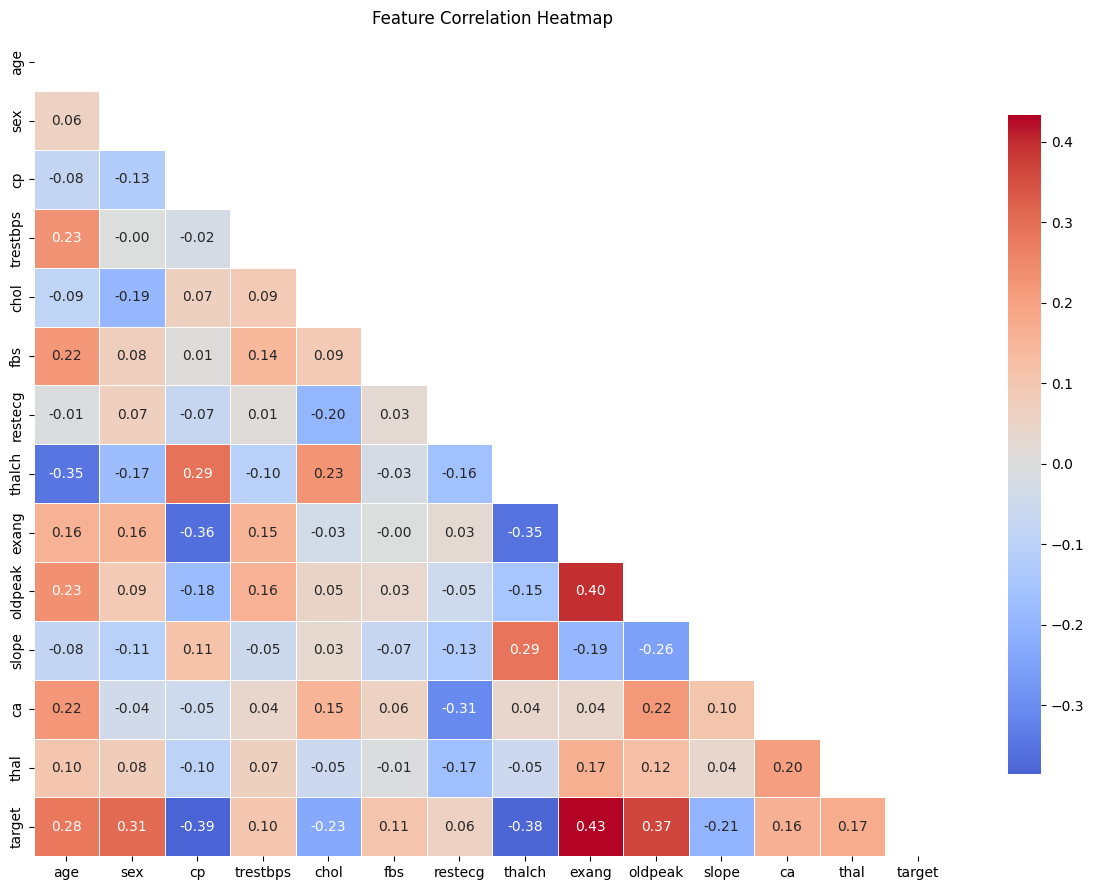

In [11]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [12]:
X = df.drop('target', axis=1)
y = df['target']
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print(f'Train: {X_train_sc.shape[0]} samples  |  Test: {X_test_sc.shape[0]} samples')
print(f'Feature count: {len(feature_names)}')

Train: 736 samples  |  Test: 184 samples
Feature count: 13


In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_proba)
print(f'Logistic Regression — Accuracy: {lr_acc:.4f}  |  ROC-AUC: {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['No Disease', 'Heart Disease']))

Logistic Regression — Accuracy: 0.8207  |  ROC-AUC: 0.8922

               precision    recall  f1-score   support

   No Disease       0.80      0.79      0.80        82
Heart Disease       0.83      0.84      0.84       102

     accuracy                           0.82       184
    macro avg       0.82      0.82      0.82       184
 weighted avg       0.82      0.82      0.82       184



In [14]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]
dt_acc = accuracy_score(y_test, dt_preds)
dt_auc = roc_auc_score(y_test, dt_proba)
print(f'Decision Tree — Accuracy: {dt_acc:.4f}  |  ROC-AUC: {dt_auc:.4f}')
print()
print(classification_report(y_test, dt_preds, target_names=['No Disease', 'Heart Disease']))

Decision Tree — Accuracy: 0.7717  |  ROC-AUC: 0.8246

               precision    recall  f1-score   support

   No Disease       0.74      0.74      0.74        82
Heart Disease       0.79      0.79      0.79       102

     accuracy                           0.77       184
    macro avg       0.77      0.77      0.77       184
 weighted avg       0.77      0.77      0.77       184



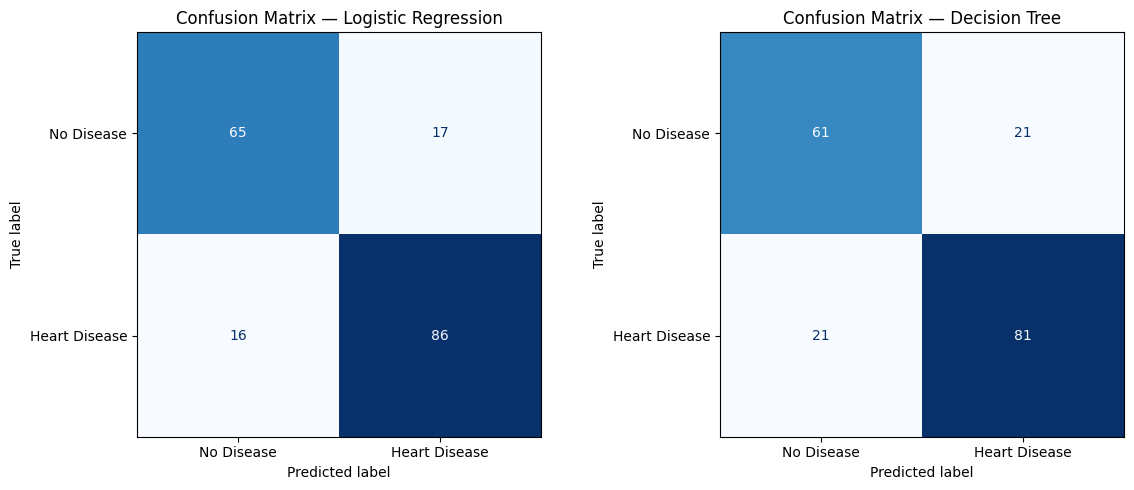

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, label in zip(axes, [lr_preds, dt_preds], ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {label}')
plt.tight_layout()
plt.show()

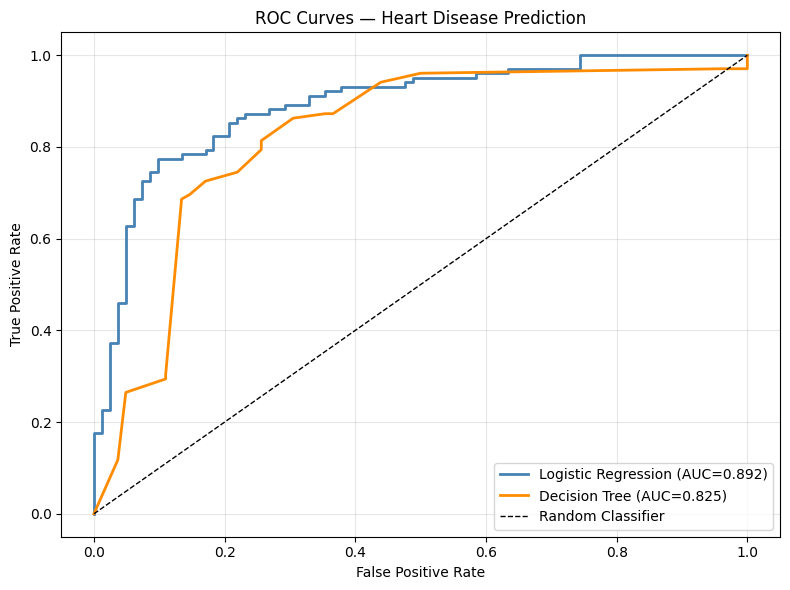

In [16]:
plt.figure(figsize=(8, 6))
for proba, label, color in [
    (lr_proba, f'Logistic Regression (AUC={lr_auc:.3f})', 'steelblue'),
    (dt_proba, f'Decision Tree (AUC={dt_auc:.3f})', 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=label, linewidth=2, color=color)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Heart Disease Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

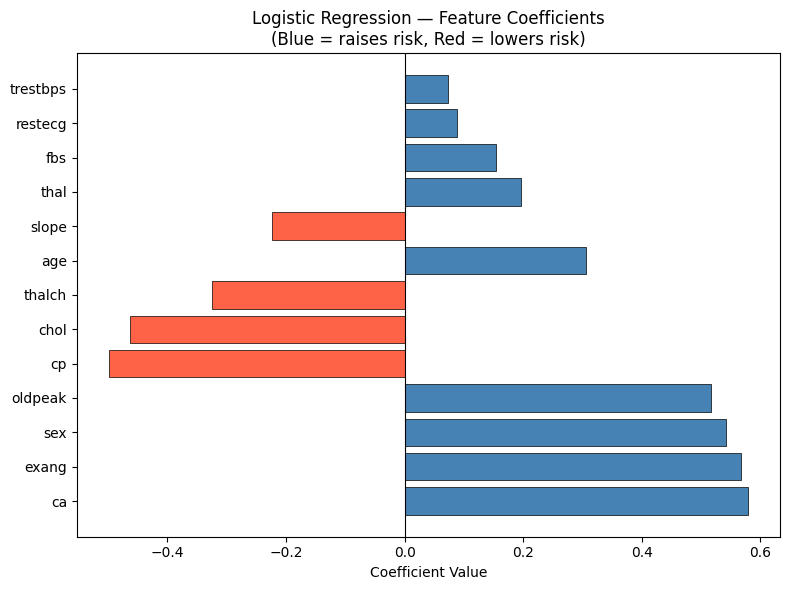

In [17]:
lr_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
colors = ['tomato' if c < 0 else 'steelblue' for c in lr_coef_df['Coefficient']]
plt.figure(figsize=(8, 6))
plt.barh(lr_coef_df['Feature'], lr_coef_df['Coefficient'], color=colors, edgecolor='k', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression — Feature Coefficients\n(Blue = raises risk, Red = lowers risk)')
plt.tight_layout()
plt.show()

C:\Users\siddi\AppData\Local\Temp\ipykernel_5628\435381994.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dt_imp_df, x='Importance', y='Feature', palette='viridis')


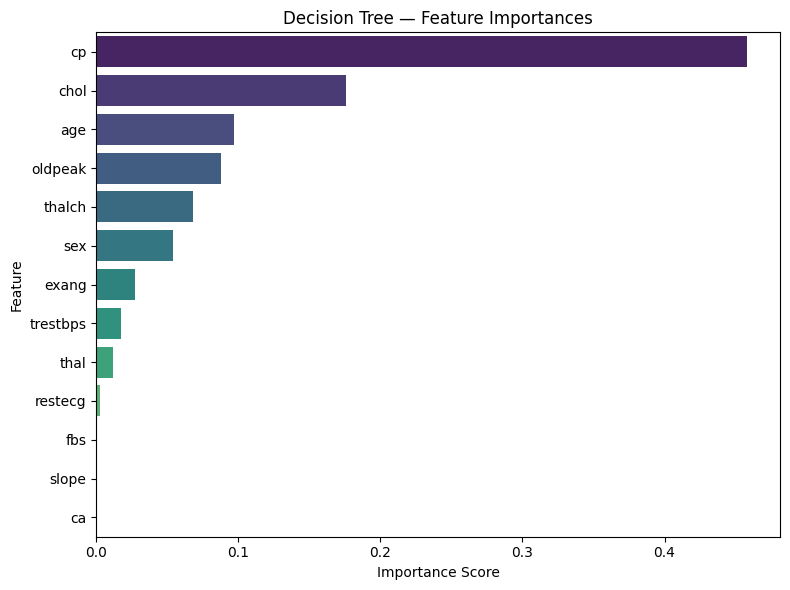

In [18]:
dt_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=dt_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Decision Tree — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

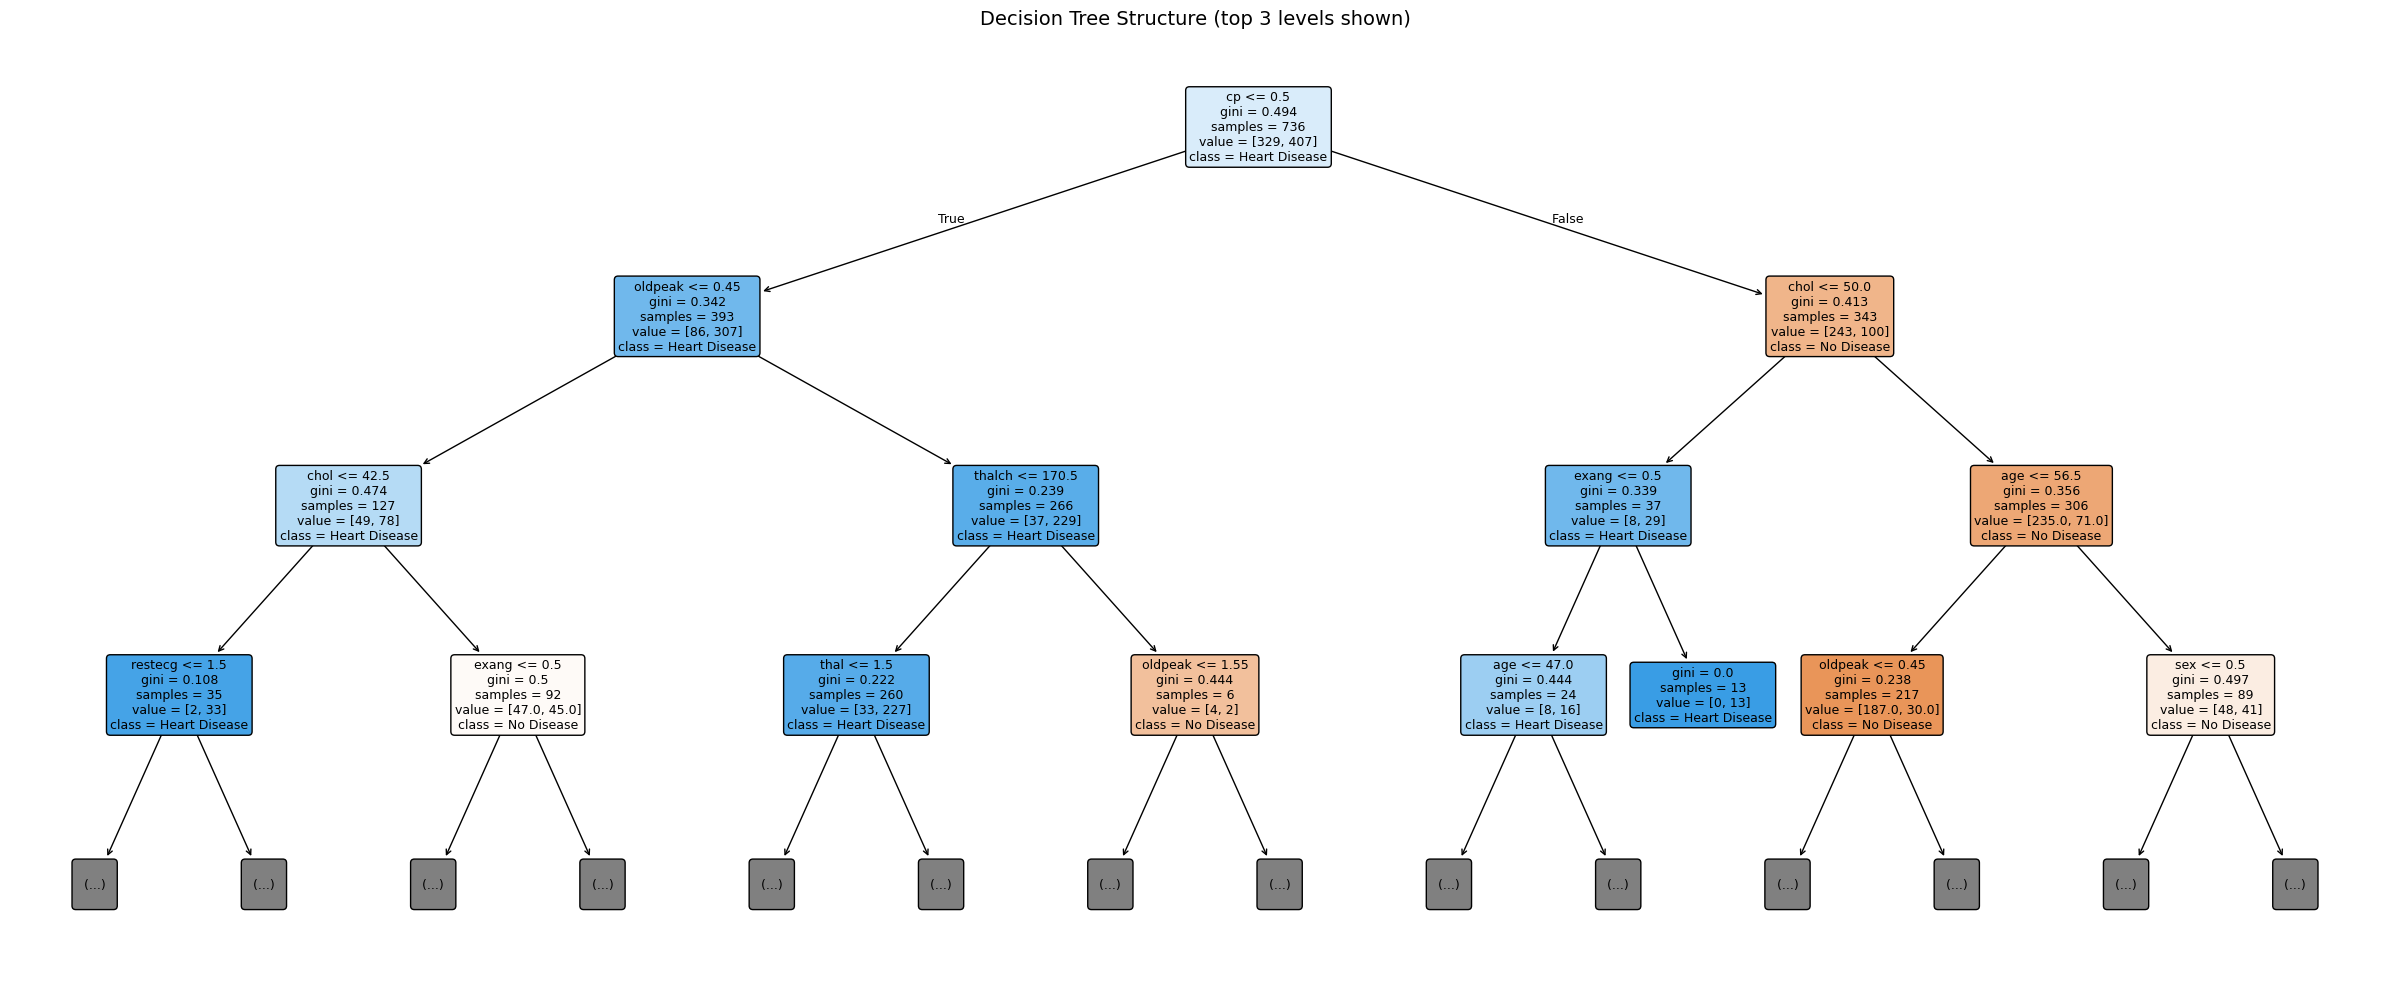

In [19]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    max_depth=3,
    ax=ax,
    fontsize=9
)
plt.title('Decision Tree Structure (top 3 levels shown)', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [round(lr_acc, 4), round(dt_acc, 4)],
    'ROC-AUC': [round(lr_auc, 4), round(dt_auc, 4)]
})
print(summary.to_string(index=False))

              Model  Accuracy  ROC-AUC
Logistic Regression    0.8207   0.8922
      Decision Tree    0.7717   0.8246
